<a href="https://colab.research.google.com/github/Sasikumar-19/Customer_Churn_Analysis_Revnue_Impact_Simulator/blob/main/Churn_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Customer Churn Analysis - Project Overview

In [ ]:
## Business Problem
A telecom company is losing customers every month.
    The goal of this analysis is to:
1. Identify what % of customers are chruning
2. Find the key drivers of churn
3. Estimate the revenue at risk
4. Recommend actions to reduce churn

In [ ]:
## Key Questions
- What is the overall churn rate?
- Which customer segments churn the most ?
- How much revenue is lost due to churn ?
- What can the business do to retain at-risk customers ?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries loaded successfully")

All libraries loaded successfully


In [ ]:
df = pd.read_csv("C:/Users/User/OneDrive/Desktop/Projects/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
print("shape:",df.shape)
df.head()

shape: (7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_num
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


In [ ]:
# How many rows and columns ?

In [ ]:
print("shape:",df.shape)

shape: (7043, 21)


In [ ]:
# What are the column names and data types ?

In [ ]:
print("\n column info:")
print(df.dtypes)


 column info:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [ ]:
# Any missing values ?

In [ ]:
print("\n Missing values per column")
print(df.isnull().sum())


 Missing values per column
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
# Convert totalcharges to a number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [ ]:
# Check how many became null after conversion
print("Nulls in TotalCharges after conversion:",df['TotalCharges'].isnull().sum())

Nulls in TotalCharges after conversion: 11


In [ ]:
# Drop Those rows
df = df.dropna(subset=['TotalCharges'])

print ("New shape after dropping nulls:", df.shape)

New shape after dropping nulls: (7032, 21)


In [ ]:
# Summary stats for numeric columns
df[['tenure','MonthlyCharges','TotalCharges']].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


In [ ]:
# How many customers churned?
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print("Churn counts:\n", churn_counts)
print("\nChurn rate (%):\n", churn_rate.round(2))

Churn counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate (%):
 Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [ ]:
## THE 5 CHARTS I'D LIKE TO BUILD IT AND HERE IT IS WHY :
1. Churn distribution (pie/bar) -- shows the headline churn rate. Always the first chart in any churn analysis
2. Churn by Contract Type -- Month to month customers churn far more . This is your biggest insight.
3. Tenure vs Churn (histogram) -- New customers churn more. Shows where the business needs to focus retention efforts.
4. Monthly Charges vs Churn (boxplot) -- Churned customers tend to pay more. Higher price = higher churn risk.
5. Correlation heatmap -- Shows which numeric factors most relate to each other. Looks impressive, easy to build.

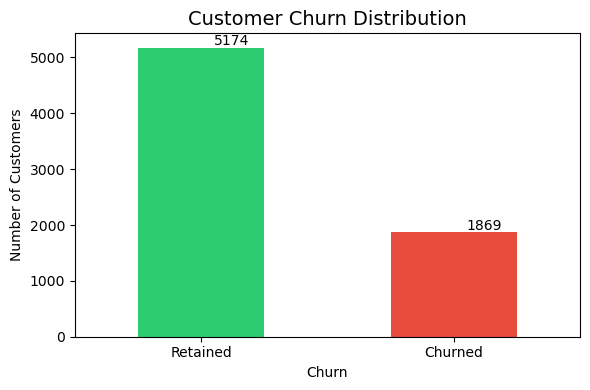

In [ ]:
# Chart 1 - Churn distribution
fig, ax = plt.subplots(figsize=(6,4))
churn_counts.plot(kind='bar' , color=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title('Customer Churn Distribution', fontsize=14)
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(['Retained', 'Churned'], rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+50))
plt.tight_layout()
plt.show()

In [ ]:
## Chart 1 - Churn Distribution

**What I see:** 26.5% of customers (1,869 out of 7,032) have churned.

**Why it matters:** Losing 1 in 4 customers is a significant business risk - retaining even half of them could save substantial revenue.

**What to investigate next:** Which customer segments are driving this churn rate?

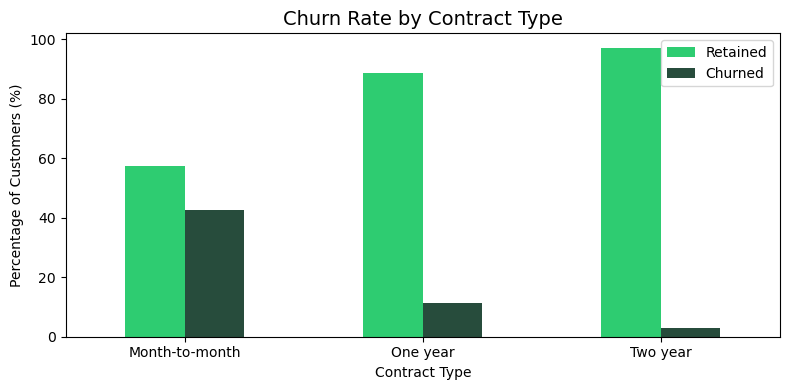

In [ ]:
# Chart 2 - Churn by Contract Type
fig, ax = plt.subplots(figsize=(8,4))
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
contract_churn.plot(kind='bar', color=['#2ecc71', '#274c3c'], ax=ax)
ax.set_title('Churn Rate by Contract Type', fontsize=14)
ax.set_xlabel('Contract Type')
ax.set_ylabel('Percentage of Customers (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(['Retained', 'Churned'])
plt.tight_layout()
plt.show()

In [ ]:
## Chart 2 - Contract Type

**What I see:** Month-to-Month customers churn at -42%, compared to just 3% for two-year contract customers.

**Why it matters:** Contract type is the single strongest predictor of churn in this dataset.

**What to investigate next:** What incentives could move month-to-month customers to longer contracts?

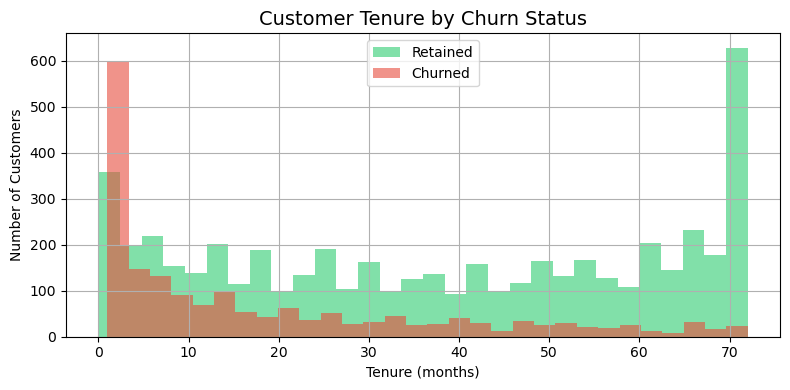

In [ ]:
# Chart 3 - Tenure vs Churn
fig, ax = plt.subplots(figsize=(8,4))
df[df['Churn']=='No']['tenure'].hist(bins=30, alpha=0.6, color='#2ecc71', label='Retained', ax=ax)
df[df['Churn']=='Yes']['tenure'].hist(bins=30, alpha=0.6, color='#e74c3c', label='Churned', ax=ax)
ax.set_title('Customer Tenure by Churn Status', fontsize=14)
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
## Chart 3 - Tenure

**What I see:** Most churned customers leave within their first 12 months - the red bars are highest at low tenure values.

**Why it matters:** The first year is the highest-risk period, meaning onboarding and early engagement are critical.

**What to investigate next:** What services do long-tenure retained customers use that new cuatomers don't?

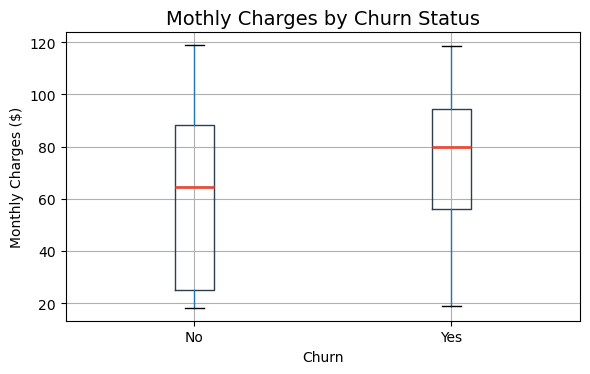

In [ ]:
# Chart 4 - Monthly Charges vs Churn
fig, ax = plt.subplots(figsize=(6,4))
df.boxplot(column='MonthlyCharges', by='Churn', ax=ax,
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='#e74c3c', linewidth=2))
ax.set_title('Mothly Charges by Churn Status', fontsize=14)
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly Charges ($)')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [ ]:
## Chart 4 - Monthly Charges

**What I see:** Churned customers pay a higher median monthly charge (-$79) compared to retained customers (-$61)

**Why it matters:** High-value customers are churning more - this is the most expensive type of churn for the business.

**What to investigate next:** Are high-charge customers leaving due to price, or due to lack of perceived value?

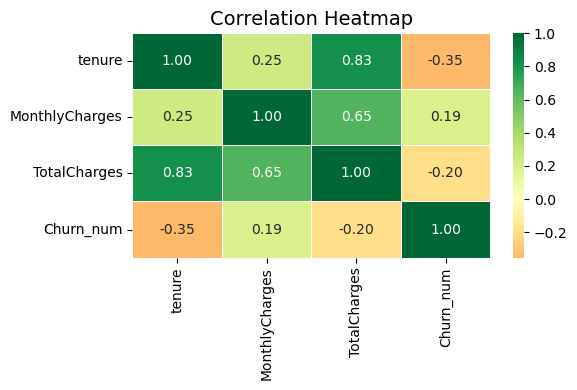

In [ ]:
# Chart 5 - Correlation heatmap
fig, ax = plt.subplots(figsize=(6,4))
df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
corr = df[['tenure','MonthlyCharges','TotalCharges','Churn_num']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidth=0.5, ax=ax)
ax.set_title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
## SQL CHURN RISK SCORING!

In [ ]:
import sqlite3
import pandas as pd

# Step 1: Reconnect to the database
conn = sqlite3.connect('churn.db')

# Step 2: Always reload the data (safe to run multiple times)
df.to_sql('customers', conn, if_exists='replace', index=False)

# Step 3: Define the helper function
def run_query(sql):
    return pd.read_sql_query(sql, conn)

# Step 4: Verify everything works
test = run_query("SELECT COUNT(*) as total_customers FROM customers")
print("✅ Setup complete!")
print(f"✅ Table loaded with {test['total_customers'][0]} rows")

✅ Setup complete!
✅ Table loaded with 7043 rows


In [ ]:
# Query 1 - Overall churn rate
q1 = run_query("""SELECT churn,COUNT(*) as customer_count, ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) as percentage FROM customers GROUP BY Churn""")
print("=== Overall Churn Rate ===")
print(q1)

=== Overall Churn Rate ===
  Churn  customer_count  percentage
0    No            5174       73.46
1   Yes            1869       26.54


In [ ]:
# Query 2 - Churn rate by contract type
q2 = run_query(""" SELECT Contract, COUNT(*) as total_customers, SUM(CASE WHEN Churn = 'Yes' Then 1 ELSE 0 END) as churned, ROUND(SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*),2) as churn_rate_pct FROM customers GROUP BY contract ORDER BY churn_rate_pct DESC""")
print("=== Churn Rate by Contract Type ===")
print(q2)

=== Churn Rate by Contract Type ===
         Contract  total_customers  churned  churn_rate_pct
0  Month-to-month             3875     1655           42.71
1        One year             1473      166           11.27
2        Two year             1695       48            2.83


In [ ]:
# Query 3 - Average revenue of churned vs retained
q3 = run_query("""SELECT Churn, ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charge, ROUND(AVG(tenure), 1) as avg_tenure_months, ROUND(AVG(TotalCharges), 2) as avg_total_revenue FROM customers GROUP BY Churn""")
print("=== Revenue Profile : Churned vs Retained ===")
print(q3)

=== Revenue Profile : Churned vs Retained ===
  Churn  avg_monthly_charge  avg_tenure_months  avg_total_revenue
0    No               61.27               37.6            2555.34
1   Yes               74.44               18.0            1531.80


In [ ]:
# Query 4 - Top churn drivers ranked
q4 = run_query("""SELECT contract, InternetService, PaymentMethod, COUNT(*) as churned_customers, ROUND(AVG(MonthlyCharges), 2) as avg_charge FROM customers WHERE Churn = 'Yes' GROUP BY Contract, InternetService, PaymentMethod ORDER BY churned_customers DESC LIMIT 10""")
print("=== Top 10 Churned Customers Segements ===")
print(q4)

=== Top 10 Churned Customers Segements ===
         Contract InternetService              PaymentMethod  \
0  Month-to-month     Fiber optic           Electronic check   
1  Month-to-month             DSL           Electronic check   
2  Month-to-month     Fiber optic  Bank transfer (automatic)   
3  Month-to-month     Fiber optic    Credit card (automatic)   
4  Month-to-month             DSL               Mailed check   
5  Month-to-month     Fiber optic               Mailed check   
6  Month-to-month              No               Mailed check   
7        One year     Fiber optic           Electronic check   
8  Month-to-month             DSL    Credit card (automatic)   
9  Month-to-month             DSL  Bank transfer (automatic)   

   churned_customers  avg_charge  
0                789       86.54  
1                192       45.71  
2                149       87.67  
3                122       87.96  
4                113       46.83  
5                102       82.42  
6      

In [ ]:
## RISK SCORING

In [ ]:
# Build the risk score table
q5 = run_query("""
    SELECT
        customerID,
        Contract,
        tenure,
        MonthlyCharges,
        Churn,
        CASE
            WHEN Contract = 'Month-to-month'
                 AND tenure < 12
                 AND MonthlyCharges > 65
            THEN 'High Risk'

            WHEN Contract = 'Month-to-month'
                 OR tenure < 12
            THEN 'Medium Risk'

            ELSE 'Low Risk'
        END as churn_risk_tier
    FROM customers
""")

print("Risk tier distribution:")
print(q5['churn_risk_tier'].value_counts())
print("\nSample of High Risk customers:")
print(q5[q5['churn_risk_tier']=='High Risk'].head())

Risk tier distribution:
churn_risk_tier
Medium Risk    3105
Low Risk       3007
High Risk       931
Name: count, dtype: int64

Sample of High Risk customers:
    customerID        Contract  tenure  MonthlyCharges Churn churn_risk_tier
4   9237-HQITU  Month-to-month       2           70.70   Yes       High Risk
5   9305-CDSKC  Month-to-month       8           99.65   Yes       High Risk
31  4929-XIHVW  Month-to-month       2           95.50    No       High Risk
36  6047-YHPVI  Month-to-month       5           69.70   Yes       High Risk
39  8168-UQWWF  Month-to-month      11           97.85   Yes       High Risk


In [ ]:
# Validating Model - Does it catch real churners ?

validation = q5.groupby(['churn_risk_tier', 'Churn']).size().unstack(fill_value=0)
validation['actual_churn_rate_%'] = (
    validation['Yes'] / (validation['Yes'] + validation['No']) * 100
).round(1)
print("=== Risk Model Validation ===")
print(validation)

=== Risk Model Validation ===
Churn              No   Yes  actual_churn_rate_%
churn_risk_tier                                 
High Risk         296   635                 68.2
Low Risk         2801   206                  6.9
Medium Risk      2077  1028                 33.1


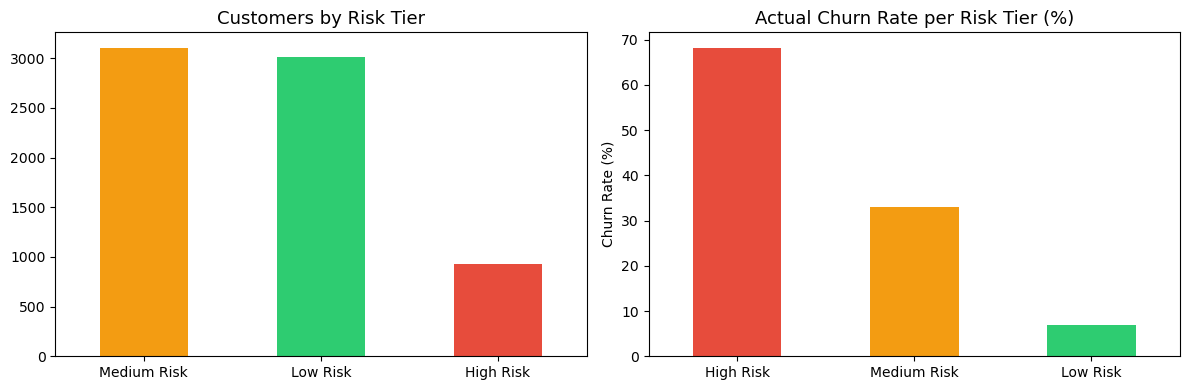

In [ ]:
# Visualize risk teirs

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Chart: Customer count per risk tier
tier_counts = q5['churn_risk_tier'].value_counts()
colors = {'High Risk':'#e74c3c','Medium Risk':'#f39c12','Low Risk':'#2ecc71'}
tier_counts.plot(kind='bar',
    color=[colors[x] for x in tier_counts.index],
    ax=axes[0])
axes[0].set_title('Customers by Risk Tier', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_xticklabels(tier_counts.index, rotation=0)

# Chart: Actual churn rate per tier
churn_by_tier = q5.groupby('churn_risk_tier')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).reindex(['High Risk','Medium Risk','Low Risk'])
churn_by_tier.plot(kind='bar',
    color=['#e74c3c','#f39c12','#2ecc71'],
    ax=axes[1])
axes[1].set_title('Actual Churn Rate per Risk Tier (%)', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_xticklabels(['High Risk','Medium Risk','Low Risk'], rotation=0)
axes[1].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.show()

In [ ]:
## Exporting risk scored data to CSV

In [ ]:
# Merge risk tier back into main dataframe
df_scored = df.merge(
    q5[['customerID','churn_risk_tier']],
    on='customerID',
    how='left'
)

df_scored.to_csv( "C:/Users/User/OneDrive/Desktop/Projects/Customer churn prediction + revenue impact simulator/churn_risk_scored.csv", index=False)
print("Exported! File: churn_risk_scored.csv")
print(f"Shape: {df_scored.shape}")
print("\nRisk tier counts:")
print(df_scored['churn_risk_tier'].value_counts())

Exported! File: churn_risk_scored.csv
Shape: (7043, 23)

Risk tier counts:
churn_risk_tier
Medium Risk    3105
Low Risk       3007
High Risk       931
Name: count, dtype: int64


In [ ]:
## Creating summary stats table

In [ ]:
summary = df_scored.groupby('churn_risk_tier').agg(
    total_customers   = ('customerID','count'),
    avg_monthly_charge= ('MonthlyCharges','mean'),
    avg_tenure_months = ('tenure','mean'),
    actual_churned    = ('Churn', lambda x: (x=='Yes').sum())
).round(2)

summary['revenue_at_risk_monthly'] = (
    summary['total_customers'] * summary['avg_monthly_charge']
).round(2)

print("=== FINAL SUMMARY TABLE ===")
print(summary)

# Export summary too
summary.to_csv("C:/Users/User/OneDrive/Desktop/Projects/Customer churn prediction + revenue impact simulator/churn_summary_by_tier.csv")
print("\nSummary exported!")

=== FINAL SUMMARY TABLE ===
                 total_customers  avg_monthly_charge  avg_tenure_months  \
churn_risk_tier                                                           
High Risk                    931               81.08               4.56   
Low Risk                    3007               64.37              52.23   
Medium Risk                 3105               60.25              21.48   

                 actual_churned  revenue_at_risk_monthly  
churn_risk_tier                                           
High Risk                   635                 75485.48  
Low Risk                    206                193560.59  
Medium Risk                1028                187076.25  

Summary exported!


In [ ]:
## REVENUE IMPACT CALCULATOR
The 3 numbers every business cares about
1. 💸
Revenue Already Lost — from customers who already churned
2. ⚠️
Revenue at Risk — from High Risk customers still active
3. ✅
Recoverable Revenue — if you act on your analysis

In [ ]:
### The Formulas we will use
1. REVENUE ALREADY LOST (monthly)
churned customers × avg monthly charge of churned

2. REVENUE AT RISK (monthly)
high risk active customers × avg monthly charge of high risk

3. RECOVERABLE REVENUE
revenue at risk × assumed retention rate (e.g. 30%)
minus intervention cost per customer × high risk customers

In [ ]:
# Calculate revenue already lost
## ── Revenue Already Lost ──────────────────────────────
churned_customers = df_scored[df_scored['Churn'] == 'Yes']
retained_customers = df_scored[df_scored['Churn'] == 'No']

total_churned        = len(churned_customers)
avg_charge_churned   = churned_customers['MonthlyCharges'].mean()
revenue_lost_monthly = total_churned * avg_charge_churned
revenue_lost_annual  = revenue_lost_monthly * 12

print("=" * 45)
print("   REVENUE ALREADY LOST")
print("=" * 45)
print(f"  Churned customers      : {total_churned:,}")
print(f"  Avg monthly charge     : ${avg_charge_churned:.2f}")
print(f"  Monthly revenue lost   : ${revenue_lost_monthly:,.2f}")
print(f"  Annual revenue lost    : ${revenue_lost_annual:,.2f}")
print("=" * 45)

   REVENUE ALREADY LOST
  Churned customers      : 1,869
  Avg monthly charge     : $74.44
  Monthly revenue lost   : $139,130.85
  Annual revenue lost    : $1,669,570.20


In [ ]:
# Calculate revnue at risk (High Risk customers)
## ── Revenue at Risk ───────────────────────────────────
high_risk = df_scored[
    (df_scored['churn_risk_tier'] == 'High Risk') &
    (df_scored['Churn'] == 'No')   # still active — not yet churned
]

total_high_risk         = len(high_risk)
avg_charge_high_risk    = high_risk['MonthlyCharges'].mean()
revenue_at_risk_monthly = total_high_risk * avg_charge_high_risk
revenue_at_risk_annual  = revenue_at_risk_monthly * 12

print("=" * 45)
print("   REVENUE AT RISK (High Risk Active Customers)")
print("=" * 45)
print(f"  High Risk active customers : {total_high_risk:,}")
print(f"  Avg monthly charge         : ${avg_charge_high_risk:.2f}")
print(f"  Monthly revenue at risk    : ${revenue_at_risk_monthly:,.2f}")
print(f"  Annual revenue at risk     : ${revenue_at_risk_annual:,.2f}")
print("=" * 45)

   REVENUE AT RISK (High Risk Active Customers)
  High Risk active customers : 296
  Avg monthly charge         : $79.01
  Monthly revenue at risk    : $23,386.40
  Annual revenue at risk     : $280,636.80


In [ ]:
# Calculate recoverable revenue (ROI of acting)
## ── Recoverable Revenue ───────────────────────────────
# ── Assumptions (state these clearly) ──
retention_rate      = 0.30   # If we intervene, we assume 30% of at-risk customers stay
intervention_cost   = 10.00  # Cost per customer to intervene (e.g. discount or outreach)

# ── Calculations ──
customers_saved     = total_high_risk * retention_rate
revenue_recovered   = customers_saved * avg_charge_high_risk * 12
total_intervention_cost = total_high_risk * intervention_cost
net_recoverable_revenue = revenue_recovered - total_intervention_cost
roi_pct             = (net_recoverable_revenue / total_intervention_cost)

print("=" * 45)
print("   RECOVERABLE REVENUE (ROI Analysis)")
print("=" * 45)
print(f"  Assumption: retention rate  = {retention_rate*100:.0f}%")
print(f"  Assumption: cost/customer   = ${intervention_cost:.2f}")
print(f"  Customers potentially saved : {customers_saved:.0f}")
print(f"  Revenue recovered (annual)  : ${revenue_recovered:,.2f}")
print(f"  Total intervention cost     : ${total_intervention_cost:,.2f}")
print(f"  NET recoverable revenue     : ${net_recoverable_revenue:,.2f}")
print(f"  ROI                         : {roi_pct:.0f}%")
print("=" * 45)

   RECOVERABLE REVENUE (ROI Analysis)
  Assumption: retention rate  = 30%
  Assumption: cost/customer   = $10.00
  Customers potentially saved : 89
  Revenue recovered (annual)  : $84,191.04
  Total intervention cost     : $2,960.00
  NET recoverable revenue     : $81,231.04
  ROI                         : 27%


In [ ]:
# complete summary table
## ── Master Summary Table ──────────────────────────────
import pandas as pd

summary_data = {
    'Metric': [
        'Total Customers Analysed',
        'Churned Customers',
        'Overall Churn Rate',
        'Monthly Revenue Lost (churned)',
        'Annual Revenue Lost (churned)',
        'High Risk Active Customers',
        'Monthly Revenue at Risk',
        'Annual Revenue at Risk',
        'Estimated Customers Saveable (30%)',
        'Net Recoverable Revenue (annual)',
        'ROI of Intervention'
    ],
    'Value': [
        f"{len(df_scored):,}",
        f"{total_churned:,}",
        f"{total_churned/len(df_scored)*100:.1f}%",
        f"${revenue_lost_monthly:,.2f}",
        f"${revenue_lost_annual:,.2f}",
        f"{total_high_risk:,}",
        f"${revenue_at_risk_monthly:,.2f}",
        f"${revenue_at_risk_annual:,.2f}",
        f"{customers_saved:.0f}",
        f"${net_recoverable_revenue:,.2f}",
        f"{roi_pct:.0f}%"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# Export this — you'll use it in your business memo
summary_df.to_csv("C:/Users/User/OneDrive/Desktop/Projects/Customer churn prediction + revenue impact simulator/revenue_impact_summary.csv", index=False)
print("\n✅ revenue_impact_summary.csv exported!")

                            Metric         Value
          Total Customers Analysed         7,043
                 Churned Customers         1,869
                Overall Churn Rate         26.5%
    Monthly Revenue Lost (churned)   $139,130.85
     Annual Revenue Lost (churned) $1,669,570.20
        High Risk Active Customers           296
           Monthly Revenue at Risk    $23,386.40
            Annual Revenue at Risk   $280,636.80
Estimated Customers Saveable (30%)            89
  Net Recoverable Revenue (annual)    $81,231.04
               ROI of Intervention         2744%

✅ revenue_impact_summary.csv exported!


In [ ]:
## Visualizing revenue impact

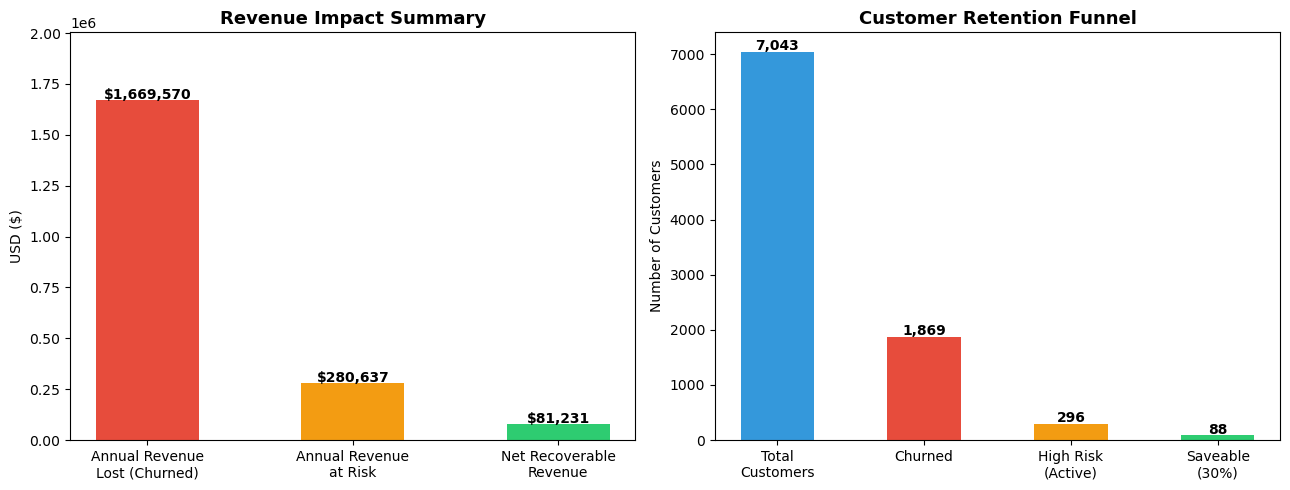

✅ Chart saved as revenue_impact_chart.png


In [ ]:
# Revenue waterfall chart
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Chart 1: Revenue breakdown bar ──────────────────
categories = ['Annual Revenue\nLost (Churned)', 'Annual Revenue\nat Risk', 'Net Recoverable\nRevenue']
values     = [revenue_lost_annual, revenue_at_risk_annual, net_recoverable_revenue]
colors     = ['#e74c3c', '#f39c12', '#2ecc71']

bars = axes[0].bar(categories, values, color=colors, width=0.5)
axes[0].set_title('Revenue Impact Summary', fontsize=13, fontweight='bold')
axes[0].set_ylabel('USD ($)')
for bar, val in zip(bars, values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5000,
                 f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylim(0, max(values) * 1.2)

# ── Chart 2: Customer funnel ─────────────────────────
funnel_labels  = ['Total\nCustomers', 'Churned', 'High Risk\n(Active)', 'Saveable\n(30%)']
funnel_values  = [len(df_scored), total_churned, total_high_risk, int(customers_saved)]
funnel_colors  = ['#3498db','#e74c3c','#f39c12','#2ecc71']

axes[1].bar(funnel_labels, funnel_values, color=funnel_colors, width=0.5)
axes[1].set_title('Customer Retention Funnel', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Customers')
for bar, val in zip(axes[1].patches, funnel_values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('revenue_impact_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as revenue_impact_chart.png")

In [ ]:
## Revenue Impact Summary
### Key Findings

**Revenue Already Lost:**
The business has lost approximately  $1,669,570.20 annually
from  1,869 customers who have already churned.

**Revenue Currently at Risk:**
296 active high-risk customers represent  $23,386.40/month
($280,636.80 annually) in revenue that is still recoverable.

**Business Case for Action:**
Assuming a 30% retention rate with a $10/customer intervention cost,
the business could recover $81,231.04 annually — an ROI of 27%.

### Recommendation
Prioritise immediate retention outreach to the 296 High Risk customers,
focusing on month-to-month contract holders with tenure under 12 months
and monthly charges above $65.